# Sanity de las metricas: runs piloto

Objetivo: comprobar, antes de ningun contraste de hipotesis, si las metricas de gradiente **tienen sentido** sobre las 24 runs del pilot de calibracion. Cuatro diagnosticos, todos apoyados en `src/analysis.py`:

1. **Validez y rangos**: NaN/Inf, columnas ausentes (metrica que fallo en runtime) y valores fuera del rango teorico, mas las identidades duras entre columnas.
2. **Degeneracion**: metricas casi constantes dentro de un run (no aportan senal temporal).
3. **Direccion vs teoria**: si la trayectoria se mueve en el sentido que predice cada paper.
4. **Redundancia**: que metricas se mueven juntas (exploratorio, anticipa la poda de redundantes).

**Alcance.** El pilot tiene **un run por celda**, asi que no hay dispersion intra-celda que correlacionar contra la eficiencia: nada de este notebook toca el plan confirmatorio congelado (`pending/Plan de analisis congelado.md`), que corre sobre la matriz en `reports/`. Las mismas funciones serviran luego para la matriz.

**Cautelas del pilot.**
- Las runs corren a **2x presupuesto**, hasta dentro del sobreajuste. `progress_frac` es relativo a ese 2x, asi que el presupuesto congelado 1x equivale a `progress_frac` 0.5. Las predicciones de los papers son sobre la fase de entrenamiento, no sobre la cola post-meseta: por eso la direccion se mira tambien en ventana temprana.
- En `tiny_imagenet` los campos de test/gap del `summary.json` estan corruptos (bug pre-fix); las metricas de la trayectoria y los campos de val/tiempo son validos.


## Setup y carga

In [1]:
import math, sys, pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Localiza la raiz del repo (carpeta con pyproject.toml) y anade src/ al path.
_p = pathlib.Path.cwd()
ROOT = next((q for q in [_p, *_p.parents] if (q / "pyproject.toml").exists()), _p)
sys.path.insert(0, str(ROOT / "src"))

import analysis as A

pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 30)
pd.set_option("display.max_rows", 60)

traj = A.load_trajectories()        # por defecto reports_pilot/
summ = A.load_summaries()
print(f"{traj['run_name'].nunique()} runs, {len(traj)} filas epoca-run")
print(f"metricas conocidas: {len(A.metric_columns())} | headline: {len(A.headline_columns())}")

24 runs, 2400 filas epoca-run
metricas conocidas: 30 | headline: 11


In [2]:
# --- helpers de ploteo (reutilizables para la matriz) -----------------------
def heatmap(df, title, cmap="RdBu_r", vmin=None, vmax=None, fmt="{:.2f}", annot=True, figsize=None):
    fig, ax = plt.subplots(figsize=figsize or (0.45 * df.shape[1] + 3, 0.32 * df.shape[0] + 2))
    data = df.to_numpy(dtype="float64")
    im = ax.imshow(data, aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_xticks(range(df.shape[1])); ax.set_xticklabels(df.columns, rotation=90, fontsize=7)
    ax.set_yticks(range(df.shape[0])); ax.set_yticklabels(df.index, fontsize=7)
    if annot:
        for i in range(df.shape[0]):
            for j in range(df.shape[1]):
                v = data[i, j]
                if pd.notna(v):
                    ax.text(j, i, fmt.format(v), ha="center", va="center", fontsize=6)
    ax.set_title(title); fig.colorbar(im, ax=ax, shrink=0.6); fig.tight_layout()
    return fig

def trajectory_grid(traj, keys, color_by="dataset", ncols=3):
    nrows = math.ceil(len(keys) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 2.8 * nrows), squeeze=False)
    cats = sorted(traj[color_by].unique()); cmap = plt.get_cmap("tab10")
    colors = {c: cmap(i % 10) for i, c in enumerate(cats)}
    for ax, key in zip(axes.flat, keys):
        for _, g in traj.groupby("run_name"):
            ax.plot(g["progress_frac"], g[key], color=colors[g[color_by].iloc[0]], alpha=0.6, lw=1)
        ax.set_title(key, fontsize=9); ax.set_xlabel("progress_frac")
    for ax in axes.flat[len(keys):]:
        ax.axis("off")
    handles = [plt.Line2D([0], [0], color=colors[c], label=c) for c in cats]
    fig.legend(handles=handles, loc="upper right", fontsize=8, ncol=len(cats))
    fig.tight_layout(); return fig

## 1. Validez y rangos

`validity_report` da, por columna conocida: rango observado, conteos de NaN/Inf, valores fuera de cota y estado. `identity_report` comprueba invariantes deterministas que **deben** cumplirse fila a fila (cualquier violacion es un bug de implementacion):

- `eta = -min_cos` (confusion).
- `min_cos <= p05_cos <= median_cos` (ordenacion de cuantiles del mismo set de cosenos).
- `gsnr median <= p95`.
- `tse/cumulative` no decreciente (suma corrida de perdidas no negativas).


In [3]:
val = A.validity_report(traj)
print("Columnas fuera de 'ok':", (val["status"] != "ok").sum(), "de", len(val))
val

Columnas fuera de 'ok': 0 de 30


,metric,family,lo,hi,obs_min,obs_max,n_nan,n_inf,n_below,n_above,runs_missing,status
key,,,,,,,,,,,,
train_loss,train_loss,monitor,0.0,NaN,2.700824e-07,9.392634,0,0,0,0,0,ok
val_loss,val_loss,monitor,0.0,NaN,1.969194e-02,71.150946,0,0,0,0,0,ok
val_acc,val_acc,monitor,0.0,1.0,2.660000e-02,0.995800,0,0,0,0,0,ok
tse/cumulative,tse,baseline,0.0,NaN,1.090947e-01,483.531458,0,0,0,0,0,ok
tse/e_window,tse,baseline,0.0,NaN,2.865300e-05,5.099071,0,0,0,0,0,ok
tse/ema_0_9,tse,baseline,0.0,NaN,1.662328e-03,47.579475,0,0,0,0,0,ok
tse/ema_0_999,tse,baseline,0.0,NaN,1.090947e-01,454.695364,0,0,0,0,0,ok
var/normalized,ngv,variability,0.0,NaN,5.556560e-01,17.330948,0,0,0,0,0,ok
var/avg,ngv,variability,0.0,NaN,1.008277e-13,0.003939,0,0,0,0,0,ok


In [4]:
A.identity_report(traj)

,n_rows,n_violations,max_violation,status
identity,,,,
eta == -min_cos,2400,0,0.000000,ok
min_cos <= p05_cos,2400,0,-0.091189,ok
p05_cos <= median_cos,2400,0,-0.003280,ok
gsnr median <= p95,2400,0,-0.000796,ok
tse/cumulative non-decreasing,2376,0,-0.000029,ok


## 2. Degeneracion (informatividad intra-run)

Para cada (run, metrica): `rel_move = within_std / ref`, donde `ref` es la RMS de los `within_std` de esa metrica (su movimiento *tipico* dentro de un run). Se normaliza por esta referencia intra-run y no por el std global a proposito: el std global esta inflado por las diferencias de escala entre datasets (val_loss en mnist ~0.05 vs tiny ~4) y marcaria como planas curvas que claramente se mueven. `rel_move` cercano a 0 = metrica practicamente constante en ese run.


In [5]:
deg = A.degeneracy_report(traj)
A.degeneracy_summary(deg).round(3)

,family,n_groups,n_degenerate,min_rel_move,median_rel_move
key,,,,,
gwa/value,alignment,24,17,0.000,0.003
val_loss,monitor,24,13,0.001,0.042
tse/ema_0_999,baseline,24,10,0.000,0.069
tse/cumulative,baseline,24,10,0.000,0.073
var/avg,variability,24,11,0.000,0.087
gwa/kurt,alignment,24,5,0.019,0.100
noise_scale/tr_sigma,variability,24,8,0.005,0.101
gwa/score_mean,alignment,24,6,0.003,0.260
stiffness/cos_global,alignment,24,4,0.020,0.325


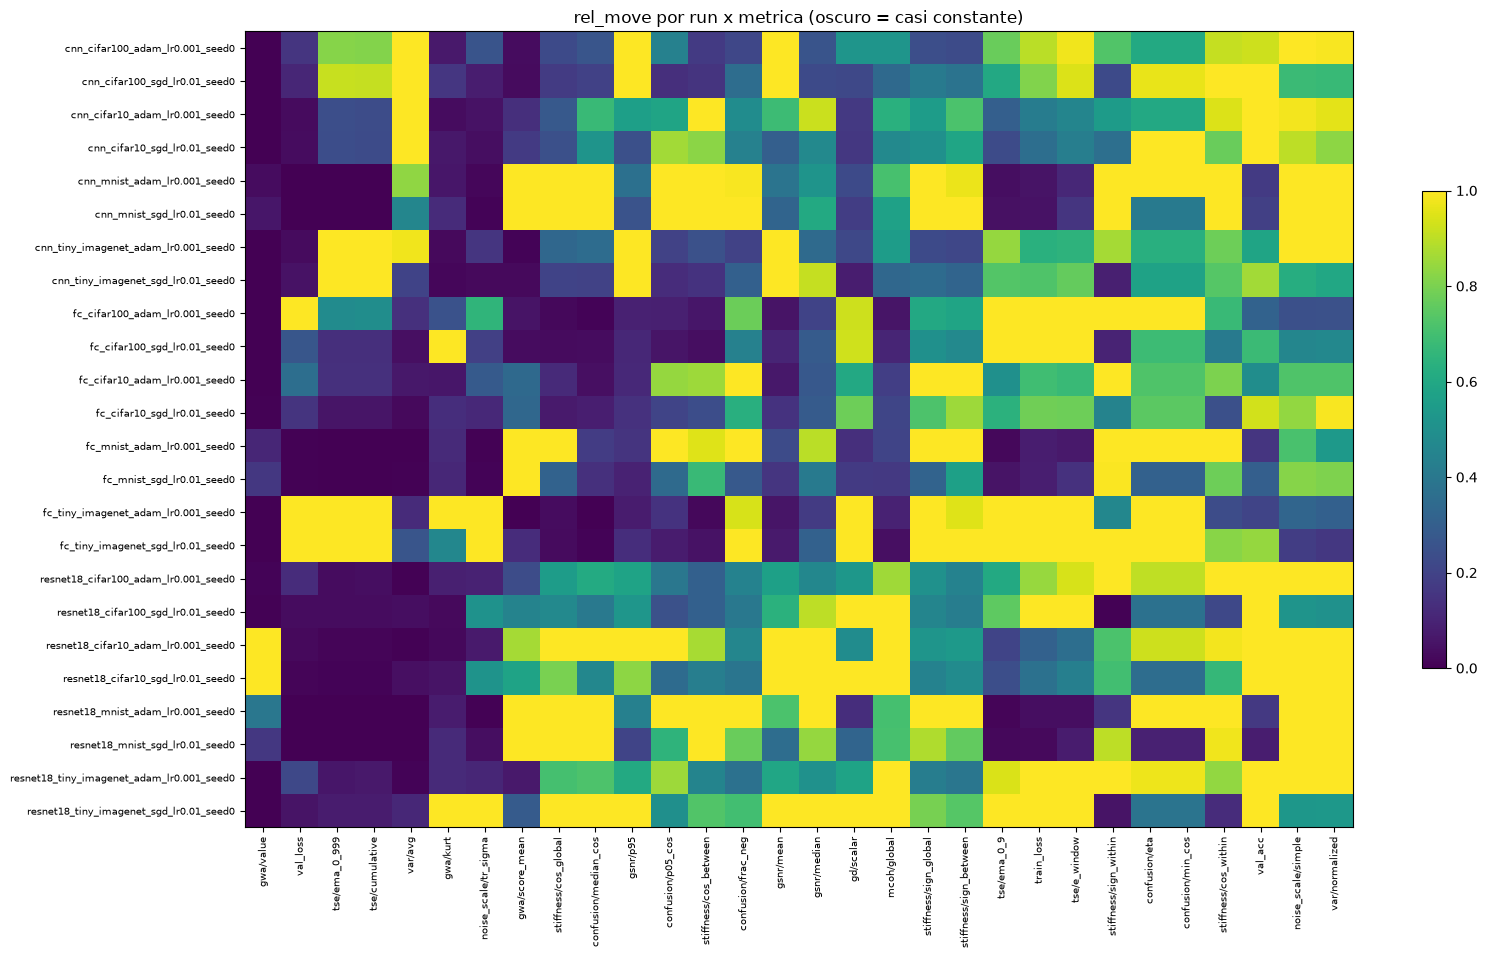

In [6]:
pivd = deg.pivot(index="run_name", columns="key", values="rel_move")
pivd = pivd[A.degeneracy_summary(deg).index]   # ordena columnas de menos a mas movil
heatmap(pivd, "rel_move por run x metrica (oscuro = casi constante)",
        cmap="viridis", vmin=0, vmax=1, annot=False);

## 3. Direccion vs teoria

`trend_report` calcula Spearman(valor, epoca) por run, solo para las metricas con prediccion direccional (las demas se reportan sin calificar). `agree` exige `|rho| >= 0.1` y el signo esperado. Se mira sobre **toda** la trayectoria y sobre la **ventana temprana** (la cola post-meseta no debe contaminar predicciones que son sobre la fase de entrenamiento).

Signos esperados: GSNR +, NGV +, GNS +, stiffness intra -, m-coherence -, gradient disparity -; y los anclajes obvios val_acc +, val_loss -, train_loss -, tse/cumulative +.


In [7]:
full = A.trend_summary(A.trend_report(traj))
early = A.trend_summary(A.trend_report(traj, progress_max=0.25))   # ~ mitad del presupuesto 1x
cmp = full[["family", "expected", "frac_agree", "median_rho"]].join(
    early[["frac_agree", "median_rho"]], rsuffix="_early")
cmp.round(3)

,family,expected,frac_agree,median_rho,frac_agree_early,median_rho_early
key,,,,,,
tse/cumulative,baseline,1,1.000,1.000,1.000,1.000
train_loss,monitor,-1,0.958,-0.735,1.000,-0.869
stiffness/cos_within,alignment,-1,0.917,-0.977,1.000,-0.987
stiffness/sign_within,alignment,-1,0.917,-0.917,0.917,-0.903
stiffness/cos_global,alignment,-1,0.667,-0.318,0.625,-0.168
mcoh/global,alignment,-1,0.625,-0.341,0.750,-0.331
noise_scale/simple,variability,1,0.625,0.341,0.750,0.331
var/normalized,variability,1,0.625,0.231,0.750,0.357
var/avg,variability,-1,0.583,-0.593,0.542,-0.466


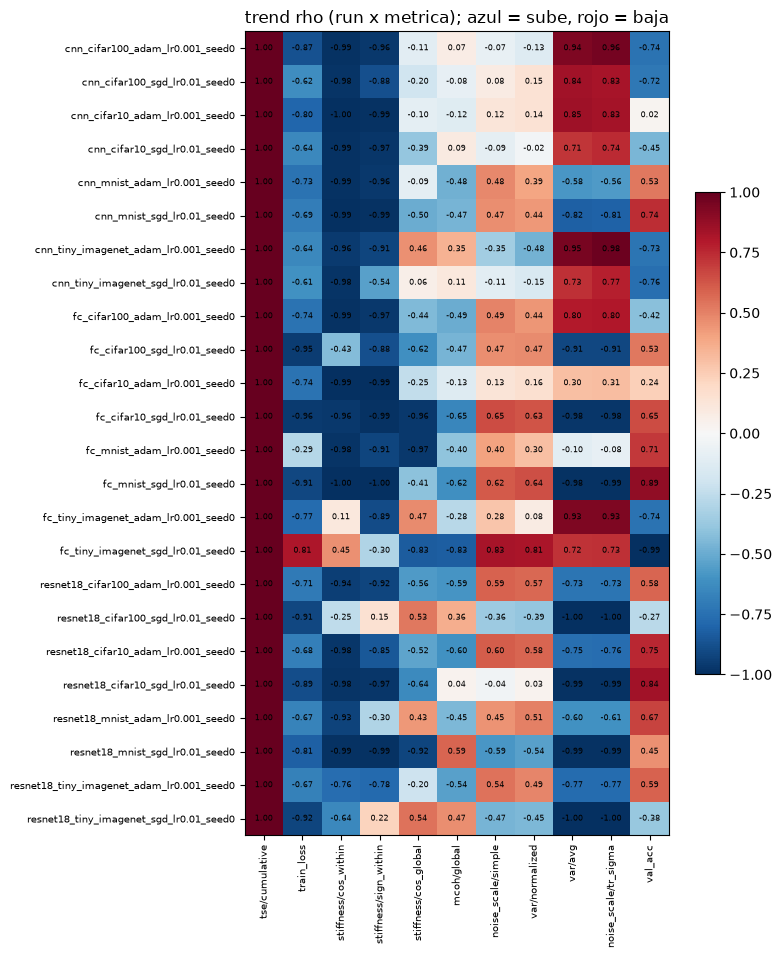

In [8]:
td = A.trend_report(traj)
piv = td.pivot(index="run_name", columns="key", values="rho")
piv = piv[full.index]   # ordena por concordancia
heatmap(piv, "trend rho (run x metrica); azul = sube, rojo = baja", vmin=-1, vmax=1);

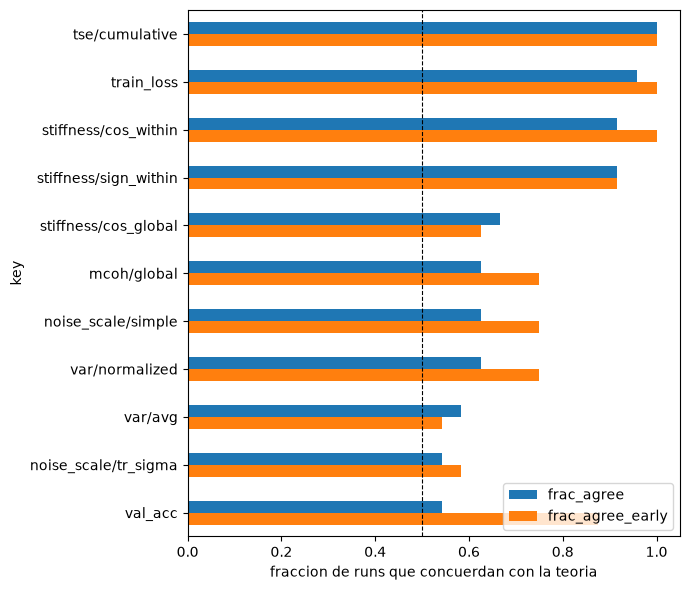

In [9]:
# frac_agree por metrica (full vs ventana temprana)
order = full.index
ax = cmp.loc[order, ["frac_agree", "frac_agree_early"]].plot.barh(
    figsize=(7, 6)); ax.set_xlabel("fraccion de runs que concuerdan con la teoria")
ax.axvline(0.5, color="k", lw=0.8, ls="--"); ax.invert_yaxis(); plt.tight_layout();

## 4. Redundancia entre metricas (exploratorio)

`redundancy_matrix` promedia las matrices de Spearman intra-run sobre las metricas headline (8 de gradiente + val_acc/val_loss + tse-ema). Promediar dentro de cada run evita que las diferencias de escala entre datasets fabriquen la correlacion (guardia de Simpson). **No es un contraste confirmatorio** ni alimenta ninguna hipotesis: es la foto previa para decidir la poda de metricas redundantes.


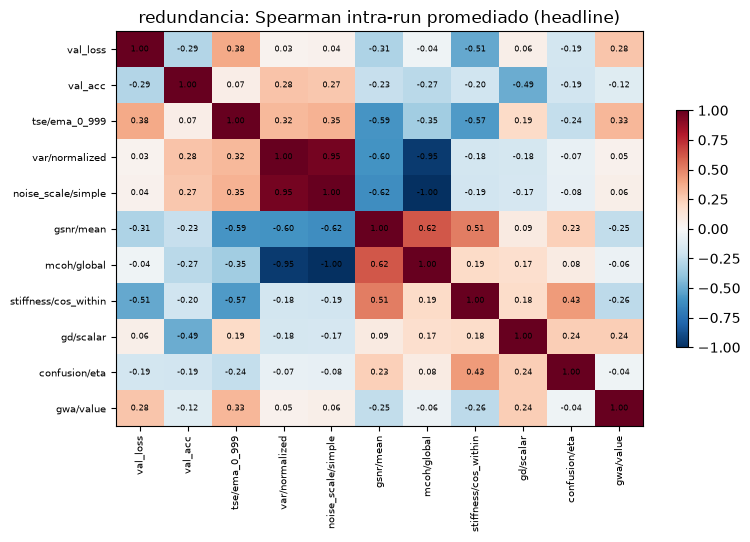

In [10]:
corr = A.redundancy_matrix(traj)
heatmap(corr, "redundancia: Spearman intra-run promediado (headline)", vmin=-1, vmax=1);

In [11]:
A.top_redundant_pairs(corr, n=12).round(3)

,a,b,rho,abs_rho
0,noise_scale/simple,mcoh/global,-1.000,1.000
1,var/normalized,noise_scale/simple,0.954,0.954
2,var/normalized,mcoh/global,-0.954,0.954
3,gsnr/mean,mcoh/global,0.624,0.624
4,noise_scale/simple,gsnr/mean,-0.624,0.624
5,var/normalized,gsnr/mean,-0.598,0.598
6,tse/ema_0_999,gsnr/mean,-0.589,0.589
7,tse/ema_0_999,stiffness/cos_within,-0.569,0.569
8,val_loss,stiffness/cos_within,-0.514,0.514
9,gsnr/mean,stiffness/cos_within,0.509,0.509


## 5. Galeria de trayectorias

Inspeccion visual final: cada metrica headline frente a `progress_frac`, una linea por run, coloreada por dataset. Es el "se mueven como deberian" a ojo, complementando los numeros de arriba.


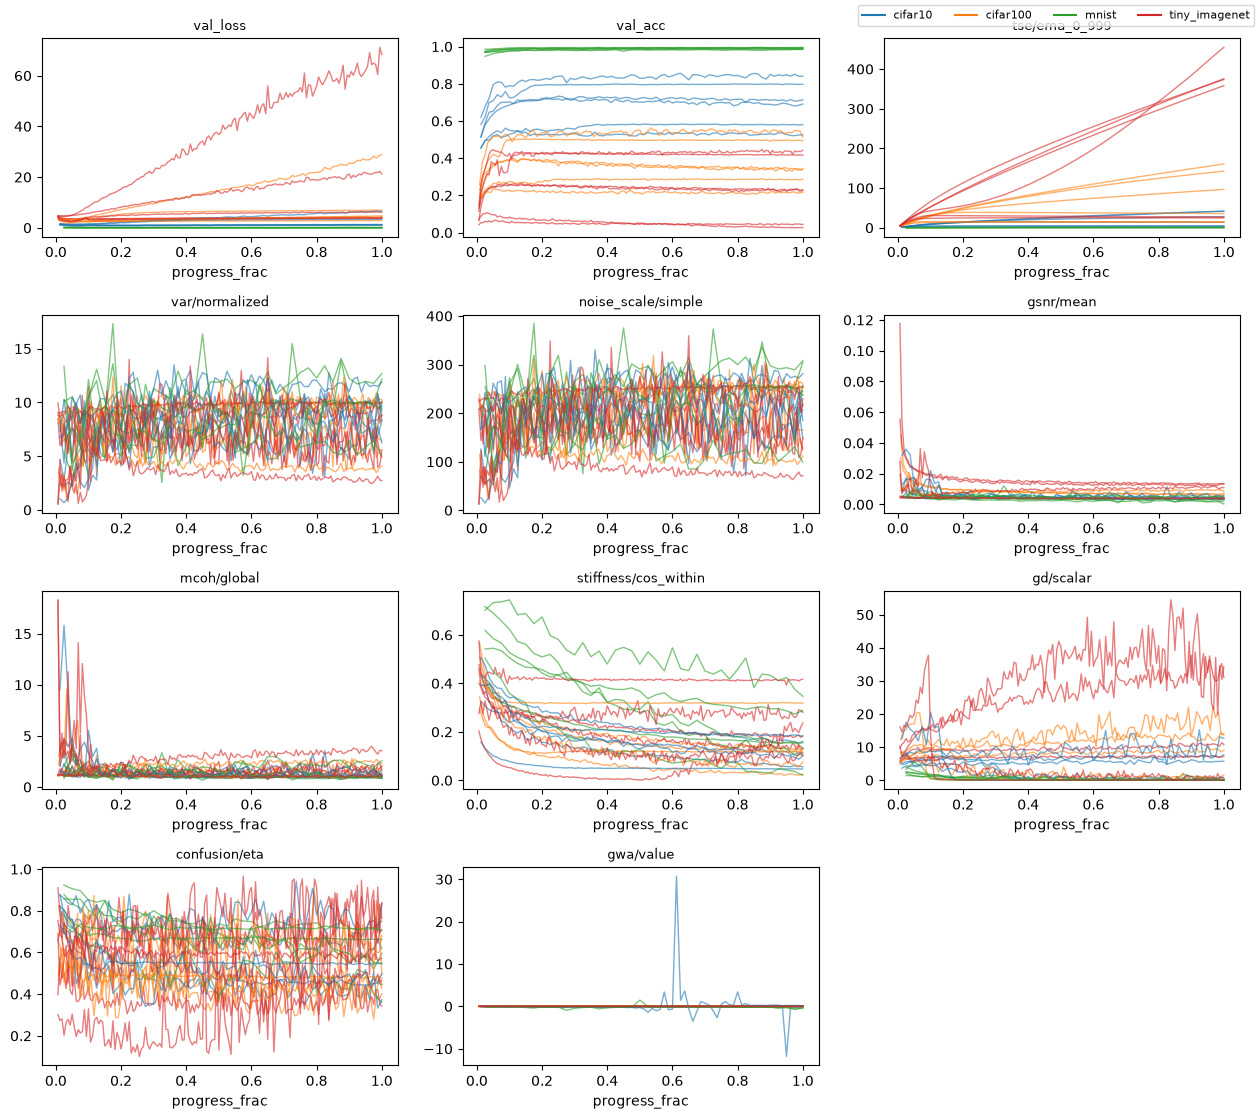

In [12]:
trajectory_grid(traj, A.headline_columns(), color_by="dataset", ncols=3);

## 6. Sintesis

Apuntar aqui las conclusiones de "tienen sentido / hay que vigilar" tras correr las celdas: validez estructural, identidades, que metricas concuerdan con su teoria, cuales degeneran y los bloques de redundancia. Estas observaciones son **descriptivas** del pilot; ninguna decision confirmatoria se toma con estos datos.
